<a href="https://colab.research.google.com/github/Kashu29/kashsish/blob/main/Sentimental_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from keras.datasets import imdb
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences
from keras import Sequential
from keras.layers import Dense,SimpleRNN, Embedding, Flatten

In [ ]:
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=10000)

In [ ]:
x_train = pad_sequences(x_train, padding='post', maxlen=50)
x_test = pad_sequences(x_test, padding='post', maxlen=50)       # 50 tokens


In [ ]:
x_train.shape

(25000, 50)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim = 10000, output_dim= 2 , input_length=50))
model.add(SimpleRNN(32, input_shape= 32, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model = Sequential()
model.add(Embedding(input_dim = 10000, output_dim= 2 , input_length=50))
model.add(SimpleRNN(32, return_sequences=False))
model.add(Dense(1, activation='sigmoid'))
model.compile(optimizer ="adam", loss = 'binary_crossentropy', metrics=['acc'])
history = model.fit(x_train, y_train , epochs = 10 , validation_data=(x_test, y_test))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - acc: 0.6393 - loss: 0.6009 - val_acc: 0.7953 - val_loss: 0.4444
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - acc: 0.8294 - loss: 0.3865 - val_acc: 0.8047 - val_loss: 0.4264
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 15s 20ms/step - acc: 0.8706 - loss: 0.3173 - val_acc: 0.8053 - val_loss: 0.4440
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 17ms/step - acc: 0.8921 - loss: 0.2738 - val_acc: 0.7994 - val_loss: 0.4664
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - acc: 0.9086 - loss: 0.2380 - val_acc: 0.7948 - val_loss: 0.5313
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - acc: 0.9248 - loss: 0.2047 - val_acc: 0.7916 - val_loss: 0.5758
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - acc: 0.9347 - loss: 0.1810 - val_acc: 0.7884 - val_loss: 0.5853
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - acc: 0.9444 - loss: 0.1583 - val_acc: 0.7791 - val_loss: 0.6271
Epoch 9/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
y_pred = model.predict(x_test)


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


In [ ]:
y_pred_labels= (y_pred > 0.5).astype(int)

In [ ]:
for i in range(5):
  print('predicted: ' , y_pred_labels[i], 'actual:' , y_test[i])

predicted:  [0] actual: 0
predicted:  [1] actual: 1
predicted:  [0] actual: 1
predicted:  [0] actual: 0
predicted:  [1] actual: 1


782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step


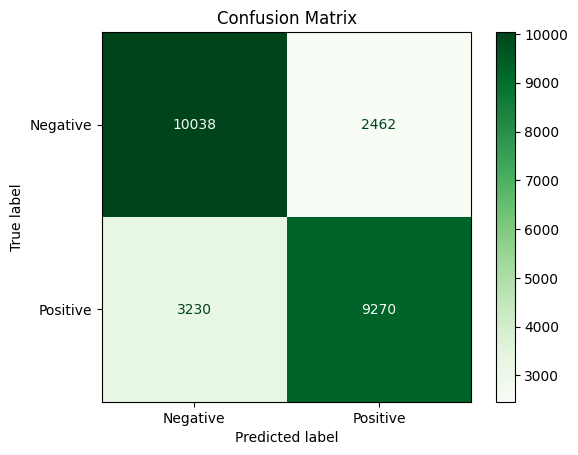

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# 1. Get predictions (probabilities)
y_pred_probs = model.predict(x_test)

# 2. Convert probabilities to 0 or 1
y_pred_labels = (y_pred_probs > 0.5).astype("int32")

# 3. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred_labels)

# 4. Plot the matrix with 'd' (decimal) formatting to stop scientific notation
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

# The 'values_format' is the key fix here
disp.plot(cmap=plt.cm.Greens, values_format='d')

plt.title('Confusion Matrix')
plt.show()


In [ ]:
text = ['Music was the Worst and th ewhole narration was worse.']

tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(text)

seq= tokenizer.texts_to_sequences(text)
padded = pad_sequences(seq, padding= 'post', maxlen= 50)

prediction = model.predict(padded)
if prediction>0.5:
  sentiment=  "Positive"
else:
  sentiment= "Negative"
print(sentiment)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
Negative
